# Lecture 14.1 Семантическая сегментация

**Цель:** понять, что именно предсказывает сегментация, как устроены основные архитектуры, как их оценивать и как запускать реальный пример на реальном датасете



## План

1. Что такое сегментация и чем она отличается от классификации  
2. Semantic, instance и panoptic segmentation  
3. Почему сегментация сложнее обычной классификации изображений  
4. Основные архитектурные идеи: FCN, U-Net, DeepLabV3  
5. Функции потерь и метрики, которые действительно нужны  
6. Реальный датасет Oxford-IIIT Pet  
7. Практический пайплайн на PyTorch  
8. Области применения, типичные ошибки и упражнения


## 1. Что такое семантическая сегментация?

Семантическая сегментация означает, что **каждому пикселю** изображения назначается метка класса.

Формулировка кажется простой, но она полностью меняет постановку задачи. В классификации модель выдает одну метку на все изображение. В детекции модель выдает набор прямоугольников. В сегментации выход — это уже не одно число и не короткий список, а плотная карта, которая должна пространственно совпадать с исходным изображением.

Это значит, что модель одновременно решает две задачи:

- понимает **что** находится в сцене  
- сохраняет достаточно геометрии, чтобы понять **где именно** проходит граница объекта

Именно поэтому сегментация находится на пересечении распознавания и локализации. Здесь нужно одновременно работать и со смыслом, и с формой.

Удобная интуиция для начинающего студента:

- классификация говорит: «на картинке есть кот»  
- детекция говорит: «кот примерно внутри этого прямоугольника»  
- сегментация говорит: «вот эти конкретные пиксели принадлежат коту»


![Segmentation pipeline](images/segmentation_pipeline.svg)

Схема выше показывает общую логику задачи: на вход подается RGB-изображение, а на выходе модель строит карту классов. Даже если внутри модели разрешение временно уменьшается, в смысловом плане задача все равно остается пиксельной.


## 2. Semantic, instance и panoptic segmentation

Эти термины постоянно встречаются вместе, и студенты часто путают их между собой.

### Semantic segmentation

Каждому пикселю назначается класс, но разные объекты одного класса не разделяются. Если на изображении три машины, все их пиксели имеют одну и ту же метку `car`.

### Instance segmentation

Теперь модель должна отделять экземпляры друг от друга. Машина №1 и машина №2 должны получить разные маски, хотя класс у них одинаковый.

### Panoptic segmentation

Это объединение двух миров:

- «stuff»-классы: небо, трава, дорога  
- «thing»-экземпляры: человек 1, человек 2, велосипед 1



Mask shape: (4, 5)
Unique labels: [0 1 2]


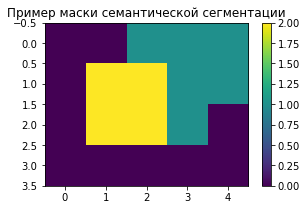

In [2]:
# Маска сегментации — это просто матрица целочисленных меток классов.

toy_mask = np.array(
    [
        [0, 0, 1, 1, 1],
        [0, 2, 2, 1, 1],
        [0, 2, 2, 1, 0],
        [0, 0, 0, 0, 0],
    ],
    dtype=np.int64,
)

print("Mask shape:", toy_mask.shape)
print("Unique labels:", np.unique(toy_mask))

if MPL_AVAILABLE:
    plt.figure(figsize=(5, 3))
    plt.imshow(toy_mask, cmap="viridis")
    plt.colorbar()
    plt.title("Пример маски семантической сегментации")
    plt.show()


## 3. Почему сегментация сложнее классификации

Классификатор может довольно агрессивно уменьшать разрешение изображения и все равно работать хорошо, потому что ему нужен только глобальный ответ. С сегментацией так нельзя. Как только мы слишком сильно сжимаем изображение, тонкие границы, маленькие объекты и мелкие детали начинают исчезать.

Отсюда возникает центральное противоречие сегментации:

- глубокие слои дают хороший семантический смысл  
- мелкие ранние слои сохраняют пространственную точность

Любая удачная архитектура сегментации так или иначе пытается совместить эти две потребности.

Если сформулировать инженерно, то главный вопрос такой:

**как одновременно сохранить достаточно контекста и достаточно разрешения?**

Именно этот вопрос объясняет, почему FCN, U-Net и DeepLab устроены именно так.


## FCN (Fully Convolutional Network)

Прежде чем подробно обсуждать U-Net и DeepLabV3, полезно увидеть их место в общей эволюции сегментации.

[Источник](https://deepmachinelearning.ru/docs/Neural-networks/Semantic-segmentation/FCN)

FCN стала одним из первых крупных шагов к современной сегментации. Она убрала полносвязные слои и показала, что классификационные CNN можно превратить в плотные предсказатели.
Одной из первых нейросетевых архитектур для решения задачи семантической сегментации была модель Fully Convolutional Network (FCN) [1], в которой использовалась полносвёрточная архитектура для семантической сегментации.

Эта архитектура состоит только из свёрток, пулингов, нелинейностей и операций повышения разрешения (upsampling).

Преимуществом архитектуры является то, что она может работать со входным изображением произвольных размеров: увеличение входа будет пропорционально увеличивать размер выхода.

Наилучшее качество работы будет достигаться при применении модели к изображениям того разрешения, которое было максимально представлено в обучающей выборке.

В простейшем случае архитектура могла бы выглядеть следующим образом [1]: ![fcn1](images/fcn1.jpg)

Однако качество сегментации подобной архитектуры будет невысоким вследствие того, что низкоразмерные промежуточные представления после резкого повышения разрешения (последний слой) не способны качественно выделять границы объектов в высоком разрешении.

Хотелось бы как-то совместить высокоуровневые информативные представления низкого разрешения с более простыми промежуточными представлениями с ранних слоёв, имеющих более высокое пространственное разрешение, чтобы точно выделять границы объектов.

Для этого в FCN предлагается прогнозировать сегментационную карту, используя не только последнее промежуточное представление (FCN-32s), но и предпоследнее. Пространственные размеры обоих прогнозов приводятся в соответствие, используя билинейную интерполяцию и складываются (FCN-16s). Этот же трюк повторяется ещё раз, когда прогнозы строятся по ещё более раннему промежуточному представлению и складываются с прогнозом FCN-16s, что даёт архитектуру FCN-8s.

Графически эта идея продемонстрирована ниже [1]:
![fcn2](images/fcn2.png)



Чем сильнее используется комбинирование прогнозов более поздних и более ранних слоёв, тем точнее работает сегментация [1]:
![fcn3](images/fcn3.png)


Литература
Long J., Shelhamer E., Darrell T. Fully convolutional networks for semantic segmentation //Proceedings of the IEEE conference on computer vision and pattern recognition. – 2015. – С. 3431-3440.

### U-Net

U-Net стала чрезвычайно популярной, потому что очень элегантно решает практическую проблему:

- encoder сжимает представление  
- decoder поднимает его обратно по разрешению  
- skip connections возвращают точные пространственные детали

Из-за этой прозрачной логики U-Net особенно удобна для обучения.

### DeepLab

Семейство DeepLab делает упор на большой receptive field и мульти-масштабный контекст через dilated convolutions и ASPP. Это сильная современная архитектурная линия, полезная для связи сегментации с более общими CNN-бэкбонами.


![U-Net architecture](images/unet_architecture.svg)

U-Net особенно полезна как учебная архитектура, потому что в ней наглядно видны почти все ключевые идеи:

- encoder-decoder структура  
- bottleneck  
- skip connections  
- плотная карта предсказаний  
- баланс между контекстом и точностью границ


## 5. U-Net

U-Net состоит из двух симметричных половин.

### Encoder

Encoder постепенно уменьшает пространственное разрешение, но увеличивает число каналов. Это помогает сети строить более абстрактные признаки. Ранние слои реагируют на края и текстуры, а более глубокие — на объектный смысл и контекст сцены.

### Bottleneck

В bottleneck модель видит изображение в минимальном разрешении. Здесь уже много семантической информации, но точные границы обычно размыты.

### Decoder

Decoder поднимает представление обратно к более высокому разрешению. Но сам по себе такой подъем часто приводит к грубым маскам.

### Skip connections

Вот почему skip connections так важны. Они передают карты признаков из encoder в соответствующие уровни decoder. Благодаря этому decoder получает:

- высокий уровень понимания от глубоких слоев  
- точную локальную структуру от неглубоких слоев

Если формулировать совсем просто:

- encoder отвечает на вопрос «что это?»  
- decoder отвечает на вопрос «где именно это находится?»  
- skip connections не дают ответу «где» стать слишком грубым


In [3]:
def binary_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)
    inter = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    return float(inter / union) if union > 0 else 1.0


def binary_dice(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)
    inter = np.logical_and(y_true, y_pred).sum()
    denom = y_true.sum() + y_pred.sum()
    return float((2 * inter) / denom) if denom > 0 else 1.0


y_true = np.array([[0, 1, 1], [0, 1, 0], [0, 0, 0]])
y_pred = np.array([[0, 1, 0], [0, 1, 1], [0, 0, 0]])

print("IoU :", round(binary_iou(y_true, y_pred), 3))
print("Dice:", round(binary_dice(y_true, y_pred), 3))


IoU : 0.5
Dice: 0.667


## 6. DeepLabV3 подробно и по шагам

DeepLabV3 решает задачу сегментации заметно иначе, чем U-Net. Не «сожмем изображение, а затем восстановим разрешение через decoder», а «возьмем сильный backbone, аккуратно расширим receptive field и соберем контекст на нескольких масштабах перед тем, как выдавать плотную маску».

DeepLabV3 ближе к тому, как многие современные segmentation-системы строятся поверх сильных pretrained backbone.

Архитектура модели DeepLabV3 выглядит следующим образом:
* Признаки извлекаются из базовой сети (VGG, DenseNet, ResNet).
* Для контроля размера карты признаков в последних нескольких блоках базовой сети используется атроусная свертка.
Поверх извлеченных из базовой сети признаков добавляется сеть ASPP для классификации каждого пикселя в соответствии с его классом.
* Выход сети ASPP проходит через свертку 1 x 1 для получения фактического размера изображения, который будет представлять собой окончательную сегментированную маску изображения.
![dlv3_1](images/dlv3_1.png)

Эти улучшения помогают извлекать плотные карты признаков для контекстов дальнего действия. Это экспоненциально увеличивает рецептивное поле без уменьшения/потери пространственного измерения и повышает производительность в задачах сегментации.

### 6.1 Почему обычного downsampling недостаточно

Если просто наращивать pooling или strided convolution, мы выигрываем в семантической абстракции, но теряем пространственную точность. Для классификации это обычно приемлемо. Для сегментации это быстро становится проблемой:

- маленькие объекты могут исчезать
- границы становятся размытыми
- тонкие структуры теряются
- модель уверенно угадывает класс, но плохо восстанавливает форму

DeepLabV3 пытается сохранить сильное семантическое представление, не жертвуя слишком большим количеством пространственной информации.

### 6.2 Atrous / dilated convolution

Первая ключевая идея — **dilated convolution** (или **atrous convolution**).

Атроусная свертка (Atrous Convolution) представлена ​​в DeepLab как инструмент для регулировки/управления эффективным полем зрения свертки. Она использует параметр, называемый «коэффициент атроусного расширения», который регулирует поле зрения. Это простая, но мощная техника для увеличения поля зрения фильтров без влияния на вычислительные затраты или количество параметров.

Атроусная свертка похожа на традиционную свертку, за исключением того, что фильтр повышает разрешение путем вставки нулей между двумя последовательными значениями фильтра вдоль каждого пространственного измерения. Вставляется r - 1 нулей, где r — коэффициент атроусного расширения. Это эквивалентно созданию r − 1 отверстий между двумя последовательными значениями фильтра в каждом пространственном измерении.

На приведенной ниже диаграмме для вычисления выходных данных применяется фильтр размером 3 с коэффициентом расширения 2. Мы можем визуализировать, что значения фильтра разделены одним отверстием, поскольку коэффициент расширения равен 2. Если коэффициент расширения r равен 1, это будет стандартная свертка.

В обычной свертке ядро читает соседние пиксели плотно. В dilated convolution точки выборки разнесены друг от друга. Это дает более широкий эффективный обзор сцены, не увеличивая радикально число параметров.

Зачем это нужно?

- модель может «видеть дальше» по изображению
- но при этом feature map сохраняет разрешение, полезное для сегментации

Это важно, потому что в сегментации локальный патч часто неоднозначен. Один пиксель шерсти, дороги или травы сам по себе может быть неочевиден. На более широком контексте решение становится проще.

![dlv3_2](images/dlv3_2.gif)![dlv3_3](images/dlv3_2.gif)


На рисунке (а) представлена ​​сверточная нейронная сеть DCNN без атроусной свертки. 
![dlv3_4](images/dlv3_4.png)
Сеть построена с использованием стандартных операций свертки и пулинга, которые уменьшают размер выходной карты признаков после каждой блочной операции. Этот тип сети очень полезен для захвата информации на больших расстояниях. Например, на рис. (а) конечный выход блока 7 с картой признаков очень малого разрешения (в 256 раз меньше исходного изображения) суммирует все признаки изображения. Однако такая карта признаков меньшего разрешения не подходит для задач семантической сегментации, требующих подробной пространственной информации.

Используя атроусную свертку, как показано на рисунке (б), мы можем сохранить пространственное разрешение и создать более глубокую сеть, захватывая признаки на каждом масштабе. Это достигается за счет увеличения коэффициента дилатации r в каждом блоке. В результате поле зрения фильтра становится шире, что необходимо для получения лучших результатов семантической сегментации.

При различном коэффициенте дилатации (dilation) r фильтр будет иметь разное поле восприятия. В результате мы можем вычислять признаки в полностью сверточных сетях для объектов разных масштабов, не уменьшая размер карт признаков. Это достигается путем применения свертки с шагом или операции пулинга в стандартных глубоких сверточных сетях.

Примечание: DeepLabV3 использует атросную свертку с шагами 6, 12 и 18.

ASPP используется для получения контекстной информации в разных масштабах. Результаты прогнозирования получаются путем повышения разрешения. В сети ASPP, помимо карты признаков, извлеченной из базовой сети, применяются четыре параллельные атроусные свертки с различными коэффициентами атроусности для сегментации объекта в разных масштабах. Также применяются признаки на уровне изображения для включения глобальной контекстной информации путем применения глобального усредняющего пулинга к последней карте признаков базовой сети. После параллельного выполнения всех операций результаты каждой операции вдоль канала объединяются, и применяется свертка 1 x 1 для получения выходных данных.

### 6.3 Receptive field и эффективный контекст

В сегментации понятие **receptive field** особенно важно. Предсказание для пикселя должно опираться на:

- локальные детали для точной границы
- широкий контекст для понимания объекта и сцены

DeepLabV3 увеличивает эффективный receptive field за счет dilated convolutions и multi-scale aggregation. Это и есть архитектурное ядро модели.

### 6.4 Output stride

Еще один важный термин в DeepLab — **output stride**. Он показывает, во сколько раз пространственное разрешение feature map меньше входного изображения.

Например:

- output stride 16 означает уменьшение разрешения в 16 раз по каждой координате
- output stride 8 сохраняет больше деталей, но требует больше памяти и вычислений

Почему студенту стоит это помнить?

Потому что output stride — это один из главных практических рычагов баланса между:

- скоростью и памятью
- и
- качеством границ и чувствительностью к маленьким объектам

### 6.5 ASPP: Atrous Spatial Pyramid Pooling

Фирменный блок DeepLabV3 — это **ASPP**.

Вместо одной фиксированной шкалы рецептивного поля ASPP строит несколько параллельных веток:

- ветку с маленьким dilation или без dilation
- ветку со средним dilation
- ветку с большим dilation
- ветку глобального pooling, которая собирает контекст всей сцены

После этого выходы веток объединяются.

Интуиция очень важна: реальные изображения содержат структуры разных масштабов. Морда животного, все тело, контур, фон сцены — все это требует разного масштаба анализа. ASPP дает модели явный способ собрать контекст сразу на нескольких шкалах.

### 6.6 Почему DeepLabV3 часто силен на практике

DeepLabV3 удачно сочетает:

- сильный pretrained backbone
- большой контекст через dilated convolutions
- явную multi-scale aggregation через ASPP

Поэтому он часто оказывается очень сильным baseline еще до серьезной кастомизации.

Полезно сравнить стили архитектур:

- U-Net делает акцент на восстановлении деталей через skip connections
- DeepLabV3 делает акцент на сильной семантике и широком контексте

Обе линии решают одну и ту же фундаментальную проблему сегментации, но разными путями.

### 6.7 DeepLabV3 vs U-Net: когда что удобно

U-Net естественно использовать, когда:

- датасет относительно небольшой
- особенно важна точность границ
- речь идет о медицине или custom small dataset
- нужна архитектура, которую легко объяснить и модифицировать

DeepLabV3 естественно использовать, когда:

- хочется опереться на сильный pretrained classification backbone
- контекст сцены очень важен
- нужен сильный готовый baseline из `torchvision`
- multi-scale context, вероятно, даст ощутимую пользу

Это не жесткое правило, а скорее хорошая учебная эвристика.


**DeepLabV3 — это segmentation-модель, которая сохраняет сильные сверточные признаки, расширяет эффективный receptive field через atrous convolutions и объединяет несколько масштабов контекста через ASPP.**


### 6.9 Сильные стороны DeepLabV3

- сильное семантическое понимание сцены
- хорошее использование pretrained backbone
- сильные baseline-результаты на многих benchmark-style датасетах
- аккуратная работа с multi-scale context

### 6.10 Слабые стороны и компромиссы

- архитектура менее интуитивна для новичка, чем U-Net
- если head слишком простой, границы все равно могут оставаться грубыми
- output stride сильно влияет на память и качество
- на очень маленьких custom datasets иногда проще контролировать более простую архитектуру

### 6.11 Почему DeepLabV3 все равно нужен в beginner-friendly лекции

Несмотря на то что DeepLabV3 чуть более абстрактен, чем U-Net, он очень важен как следующий учебный шаг, потому что на нем хорошо объясняются:

- receptive field
- multi-scale features
- dense prediction поверх pretrained backbone
- отличие segmentation-моделей от обычных classification CNN



## 7. Выходные тензоры и функции потерь

Что именно модель предсказывает на уровне тензоров?

Для семантической сегментации с `C` классами сырой выход модели обычно имеет форму:

`(batch, C, height, width)`

Это означает:

- для каждого изображения в батче  
- для каждого класса  
- для каждой пространственной позиции  
- модель выдает score

Эти score обычно называют **logits**. Класс пикселя — это индекс максимального logit.

### Cross-entropy

Самая распространенная функция потерь — пиксельная cross-entropy. Она сравнивает распределение классов в каждой точке с истинной меткой.

### Dice-подобные потери

Dice часто используют там, где положительный объект маленький, а дисбаланс классов велик, например в медицинской сегментации. Такая потеря напрямую поощряет хорошее перекрытие масок.

Практический вывод:

Если передний план очень маленький, наивное обучение легко уводит модель в сторону фона. Поэтому в сегментации важно следить не только за loss, но и за IoU/Dice.


In [5]:
if not TORCH_AVAILABLE:
    print("Для пайплайна сегментации нужен PyTorch.")
else:
    from torchvision.datasets import OxfordIIITPet
    from torchvision.transforms import v2 as T

    DATA_ROOT = Path.cwd() / "data" / "oxford_pet"
    IMAGE_SIZE = 160
    BATCH_SIZE = 8
    NUM_CLASSES = 3  # фон, питомец, контур

    image_tf = T.Compose(
        [
            T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            T.ToImage(),
            T.ToDtype(torch.float32, scale=True),
        ]
    )

    mask_tf = T.Compose(
        [
            T.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=T.InterpolationMode.NEAREST),
            T.ToImage(),
        ]
    )

    class OxfordPetSegmentation(Dataset):
        def __init__(self, root: Path, split: str = "trainval"):
            self.ds = OxfordIIITPet(
                root=root,
                split=split,
                target_types="segmentation",
                download=True,
            )

        def __len__(self):
            return len(self.ds)

        def __getitem__(self, idx):
            image, trimap = self.ds[idx]
            image = image_tf(image)
            trimap = mask_tf(trimap).squeeze(0).long()
            trimap = torch.clamp(trimap - 1, min=0, max=2)
            return image, trimap

    pet_train = OxfordPetSegmentation(DATA_ROOT, split="trainval")
    pet_test = OxfordPetSegmentation(DATA_ROOT, split="test")

    print("Train samples:", len(pet_train))
    print("Test samples :", len(pet_test))


ImportError: cannot import name 'OxfordIIITPet' from 'torchvision.datasets' (/Users/hiber/miniforge3/envs/venv/lib/python3.8/site-packages/torchvision/datasets/__init__.py)

In [ ]:
if not TORCH_AVAILABLE:
    print("Пропуск визуализации: PyTorch недоступен.")
else:
    sample_image, sample_mask = pet_train[0]
    print("Image tensor shape:", tuple(sample_image.shape))
    print("Mask tensor shape :", tuple(sample_mask.shape))
    print("Mask labels       :", torch.unique(sample_mask).tolist())

    if MPL_AVAILABLE:
        fig, axes = plt.subplots(1, 2, figsize=(9, 4))
        axes[0].imshow(sample_image.permute(1, 2, 0))
        axes[0].set_title("Изображение Oxford-IIIT Pet")
        axes[0].axis("off")

        axes[1].imshow(sample_mask, cmap="viridis")
        axes[1].set_title("Trimap / маска классов")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()


## 8. Метрики, которые нельзя игнорировать

### Pixel accuracy

Доля правильно предсказанных пикселей. Считать легко, но метрика часто слишком оптимистична.

### IoU

$$
IoU = \frac{TP}{TP + FP + FN}
$$

IoU показывает качество перекрытия предсказанной и истинной области. Она более честно учитывает и ложные срабатывания, и пропуски.

### Dice

$$
Dice = \frac{2TP}{2TP + FP + FN}
$$

Dice очень близка по смыслу к IoU и особенно популярна в задачах, где целевой объект маленький.

Если нужно запомнить одну мысль, то вот она:

**высокая pixel accuracy не гарантирует хорошую маску.**


In [6]:
if not TORCH_AVAILABLE:
    print("Пропуск создания модели: PyTorch недоступен.")
else:
    from torchvision.models.segmentation import (
        DeepLabV3_ResNet50_Weights,
        deeplabv3_resnet50,
    )

    weights = DeepLabV3_ResNet50_Weights.DEFAULT
    model = deeplabv3_resnet50(weights=weights)
    model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Total params    :", f"{total_params:,}")
    print("Trainable params:", f"{trainable_params:,}")


ImportError: cannot import name 'DeepLabV3_ResNet50_Weights' from 'torchvision.models.segmentation' (/Users/hiber/miniforge3/envs/venv/lib/python3.8/site-packages/torchvision/models/segmentation/__init__.py)

## 9. Реальный датасет: Oxford-IIIT Pet



In [ ]:
if not TORCH_AVAILABLE:
    print("Пропуск цикла обучения: PyTorch недоступен.")
else:
    SMALL_TRAIN_SIZE = 120
    SMALL_VAL_SIZE = 32
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    small_train = torch.utils.data.Subset(pet_train, list(range(SMALL_TRAIN_SIZE)))
    small_val = torch.utils.data.Subset(pet_test, list(range(SMALL_VAL_SIZE)))

    train_loader = DataLoader(small_train, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(small_val, batch_size=BATCH_SIZE, shuffle=False)

    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    def evaluate_pixel_accuracy(loader):
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, masks in loader:
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)
                logits = model(images)["out"]
                preds = logits.argmax(dim=1)
                correct += (preds == masks).sum().item()
                total += masks.numel()
        return correct / max(total, 1)

    model.train()
    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)["out"]
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        break

    val_acc = evaluate_pixel_accuracy(val_loader)
    print("Демо-шаг обучения завершен.")
    print("Validation pixel accuracy after the demo step:", round(val_acc, 4))


## 10. Где сегментация применяется на практике

Сегментация нужна везде, где важна форма объекта, а не только его наличие.

Типичные примеры:

- автопилоты: дорога, бордюр, полоса, пешеходная зона  
- медицина: опухоли, органы, сосуды, поражения  
- спутниковые снимки: дороги, здания, вода, растительность  
- робототехника: свободное пространство и зоны взаимодействия  
- сельское хозяйство: растения, сорняки, пораженные участки листьев

Простое инженерное правило:

- если достаточно прямоугольника, дешевле использовать детекцию  
- если важны границы, нужна сегментация


In [ ]:
if not TORCH_AVAILABLE:
    print("Пропуск инференса: PyTorch недоступен.")
else:
    model.eval()
    demo_image, demo_mask = pet_test[1]

    with torch.no_grad():
        logits = model(demo_image.unsqueeze(0).to(DEVICE))["out"]
        pred_mask = logits.argmax(dim=1).squeeze(0).cpu()

    if MPL_AVAILABLE:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(demo_image.permute(1, 2, 0))
        axes[0].set_title("Входное изображение")
        axes[0].axis("off")

        axes[1].imshow(demo_mask, cmap="viridis")
        axes[1].set_title("Истинная маска")
        axes[1].axis("off")

        axes[2].imshow(pred_mask, cmap="viridis")
        axes[2].set_title("Предсказанная маска")
        axes[2].axis("off")
        plt.tight_layout()
        plt.show()


## 11. Типичные ошибки

- ресайз маски неправильной интерполяцией  
- слишком большое доверие accuracy  
- забывыть визуализировать предсказания  
- игнорирование дисбаланс классов  
- слишком мало примеров и ожидание идеальных границ

Типовые качественные ошибки модели:
- грубые края  
- исчезновение маленьких объектов  
- "дырки" внутри объекта  
- правильный класс, но неправильная форма

Поэтому в сегментации визуализация `image / mask / prediction` — это не украшение, а обязательный этап отладки.


In [7]:
# Заготовка упражнения: переключитесь с DeepLabV3 на собственный U-Net

if not TORCH_AVAILABLE:
    print("Для упражнения с U-Net нужен PyTorch.")
else:
    from importlib.util import module_from_spec, spec_from_file_location

    candidate_paths = [
        Path.cwd().parent / "lecture13. PyTorch" / "U-Net" / "unet_network.py",
        Path("/Users/hiber/repositories/courses/ml/ml_course_en/lecture13. PyTorch/U-Net/unet_network.py"),
    ]

    unet_path = next((p for p in candidate_paths if p.exists()), None)
    if unet_path is None:
        print("Локальная реализация U-Net не найдена.")
    else:
        spec = spec_from_file_location("local_unet", unet_path)
        module = module_from_spec(spec)
        spec.loader.exec_module(module)
        unet = module.UNet(in_channels=3, out_channels=NUM_CLASSES, init_features=16)
        print(unet.__class__.__name__)


NameError: name 'NUM_CLASSES' is not defined

## Упражнения

1. Замените DeepLabV3 на U-Net и сравните скорость и качество.  
2. Посчитайте IoU по классам, а не только pixel accuracy.  
3. Увеличьте размер входного изображения и посмотрите на цену по памяти и выигрыш по четкости масок.  
4. Обучайте дольше и посмотрите, что улучшается раньше: глобальная форма или границы.


## Источники

- Материал расширен на основе материалов курса и заметок [deepmachinelearning.ru](https://deepmachinelearning.ru/docs/Neural-networks/Object-detection).  
- Документация `torchvision` по Oxford-IIIT Pet и segmentation models.  
- Статья про U-Net: *U-Net: Convolutional Networks for Biomedical Image Segmentation*.  
- Линия работ DeepLab по dilated convolutions и ASPP.
